Canaux: 21 | Catégories: ['Eai', 'Narco', 'Syn', 'TCSPi'] | Bande: Gamma_Haut | Valeur: rel
[INFO] Canaux sélectionnés: ['Fp1-T3', 'Fp1-C3', 'T3-O1', 'Fp2-T4', 'Fp2-C4', 'T4-O2', 'Fp1-A1', 'Fp2-A1', 'T3-A1', 'C3-A1', 'T4-A1', 'C4-A1']


/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


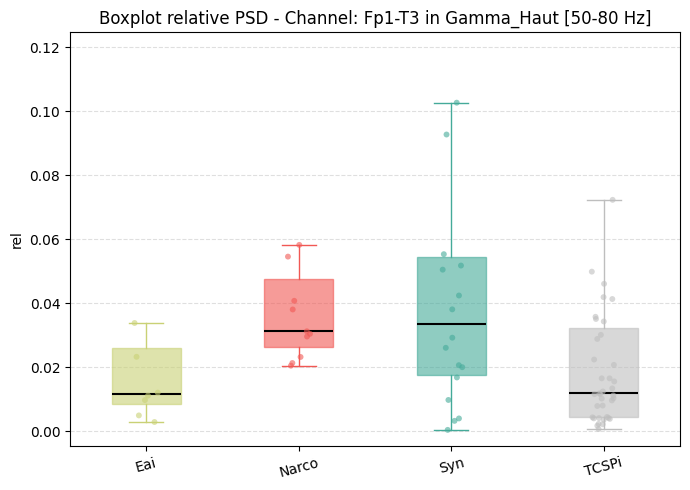

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


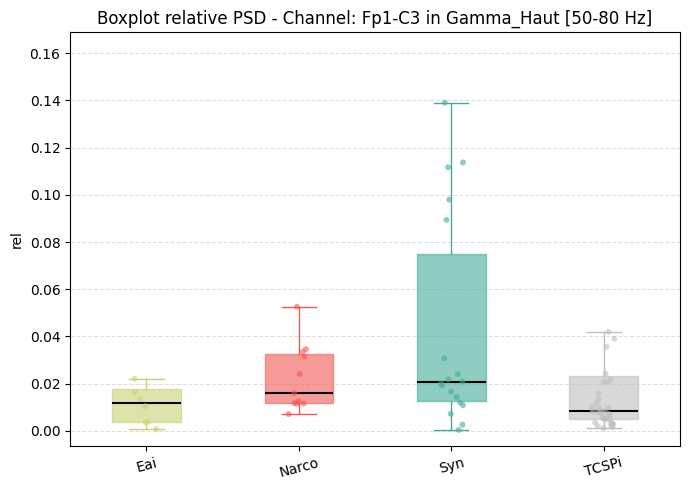

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


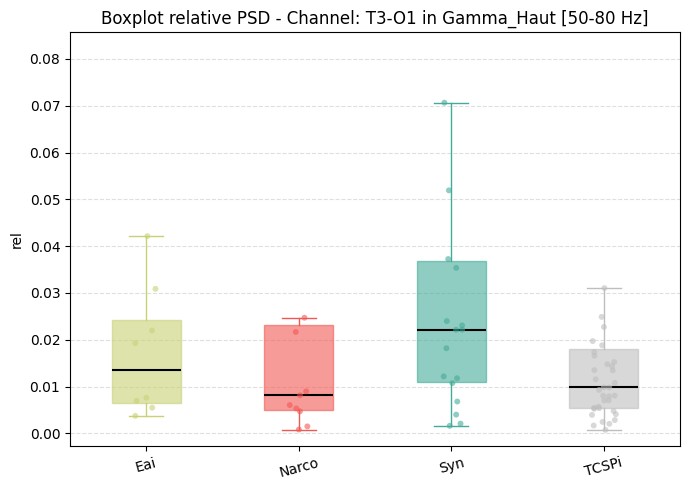

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


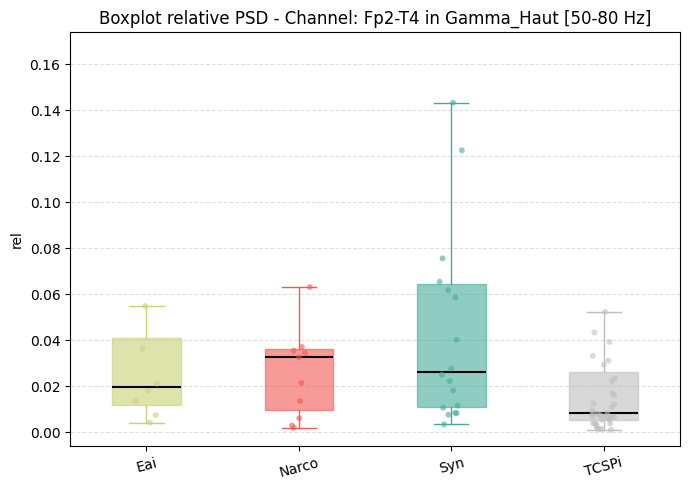

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


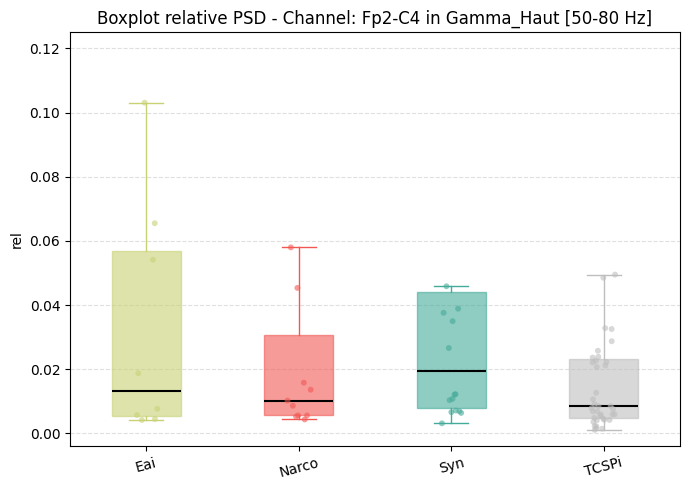

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


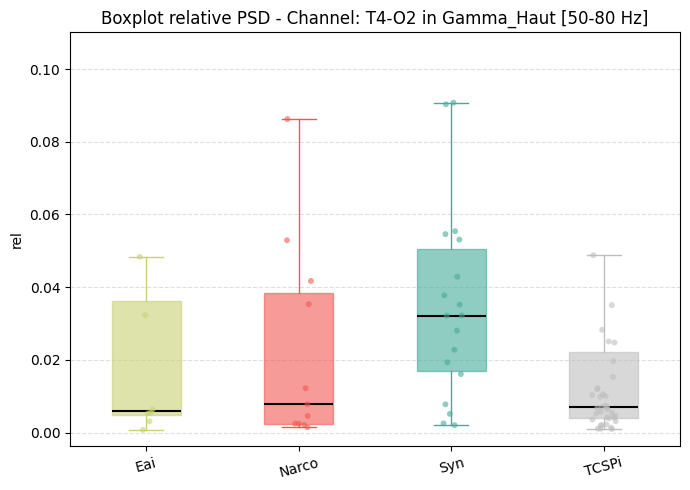

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


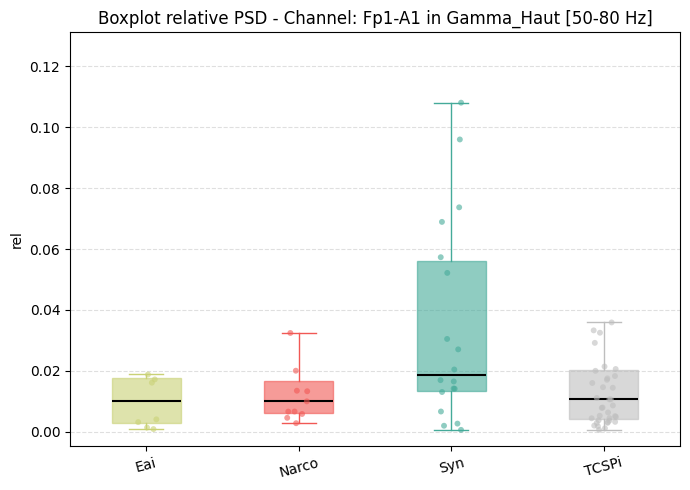

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


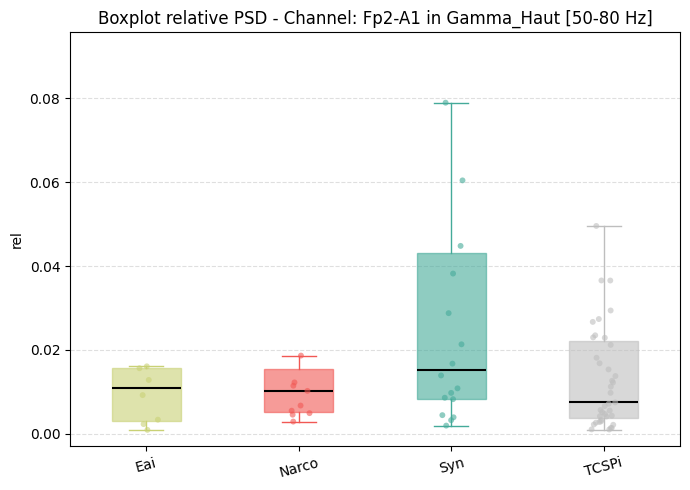

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


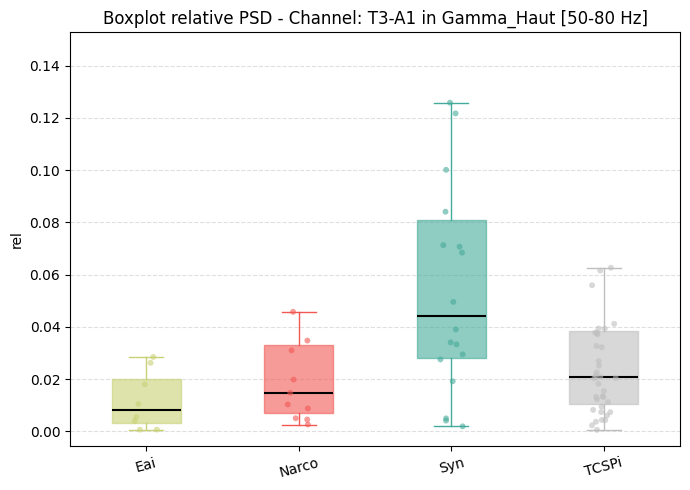

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


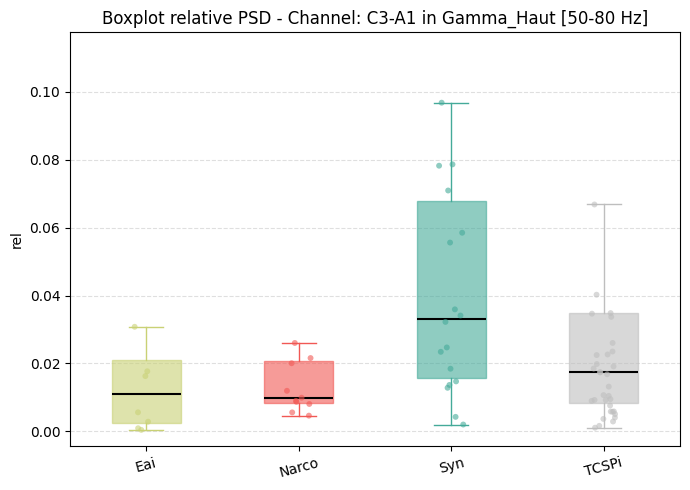

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


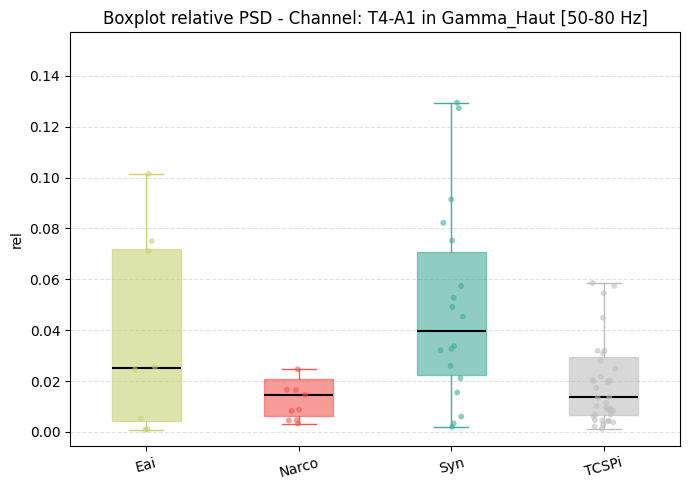

/tmp/ipykernel_3687653/3772748179.py:133: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


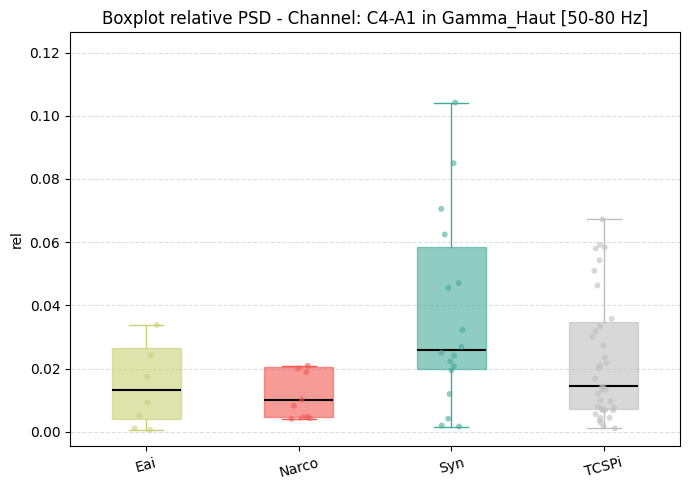

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# === Paramètres à ajuster rapidement ===
CSV_PATH = "../../documents/EEG/results/psd_rswa_epo/per_channel_band_powers.csv" 
VALUE_COL = "rel"        # "rel" ou "abs"
BAND = "Gamma_Haut"           # ex: "Delta", "Theta", "Alpha", "Beta", "Gamma_Bas" ou "Gamma_Haut"
SAVE_DIR = None        # None pour ne pas sauvegarder

# === Palette demandée ===
PALETTE = {
    "Eai": "#C9D175", 
    "Narco": "#F15854",  
    "Syn": "#44AA99",  
    "TCSPi": "#BEBEBE", 
    "Unknown": "#000000",
}
DEFAULT_COLOR = "#777777" # Gris par défaut si groupe inconnu


# === Bandes de fréquence ===
BAND_FREQS = {
    "Delta":      (0.5, 4),
    "Theta":      (4, 8),
    "Alpha":      (8, 13),
    "Beta":       (13, 30),
    "Gamma_Bas":  (30, 50),   
    "Gamma_Haut": (50, 80),   
}

# ===== Réglages d'affichage des points =====
SHOW_POINTS = True
JITTER_WIDTH = 0.08   # amplitude du jitter horizontal 
POINT_SIZE = 18       # taille des marqueurs
POINT_ALPHA = 0.6     # transparence des points


# ===== Helper : Ne pas afficher les outliers du boxplot =====
def iqr_whisker_bounds(a):
    """Bornes whisker (1.5*IQR) comme le boxplot matplotlib."""
    if len(a) == 0:
        return -np.inf, np.inf
    q1 = np.percentile(a, 25)
    q3 = np.percentile(a, 75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


# === Chargement ===
df = pd.read_csv(CSV_PATH)

# Renommer les catégories dans les données
GROUP_RENAME = {
    "autoimmune encephalitides": "Eai",
    "narcolepsy":                "Narco",
    "synucleopathy":             "Syn",
    "tcspi":                     "TCSPi",
    "unknown":                   "Unknown",
}
df["group"] = df["group"].replace(GROUP_RENAME)

# Vérifs
required_cols = {"channel", "band", VALUE_COL, "group"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Colonnes manquantes dans le CSV: {missing}. "
                     f"Colonnes trouvées: {list(df.columns)}")

# Filtre bande
sub = df[df["band"] == BAND].copy()
if sub.empty:
    raise ValueError(f"Aucune ligne trouvée pour la bande '{BAND}'. "
                     f"Bandes dispo: {sorted(df['band'].unique())}")

# Catégories et couleurs associées
groups = sorted(sub["group"].dropna().unique())
group_colors = [PALETTE.get(g, DEFAULT_COLOR) for g in groups]
if len(groups) < 2:
    print("Il n'y a qu'une seule catégorie dans 'group'. "
          "Le boxplot comparatif aura peu d'intérêt.")

# Prépare dossier de sauvegarde si demandé
if SAVE_DIR:
    Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

channels = sorted(sub["channel"].dropna().unique())
print(f"Canaux: {len(channels)} | Catégories: {groups} | Bande: {BAND} | Valeur: {VALUE_COL}")

# === Canaux à afficher ===
pairs = [
    ("Fp1", "T3",  "Fp1-T3"),
    ("Fp1", "C3",  "Fp1-C3"),
    ("T3",  "O1",  "T3-O1"),
    ("Fp2", "T4",  "Fp2-T4"),
    ("Fp2", "C4",  "Fp2-C4"),
    ("T4",  "O2",  "T4-O2"),
    ("Fp1", "A1", "Fp1-A1"),
    ("Fp2", "A1", "Fp2-A1"),
    ("T3", "A1", "T3-A1"),
    ("C3", "A1", "C3-A1"),
    ("T4", "A1", "T4-A1"),
    ("C4", "A1", "C4-A1"),
]

wanted = [lab for *_ , lab in pairs]
wanted_set = set(wanted)

# Filtre (garde l'ordre de wanted)
available = set(channels)
channels = [ch for ch in wanted if ch in available]

missing = [ch for ch in wanted if ch not in available]
if missing:
    print("[WARN] Canaux demandés absents du CSV:", missing)

print("[INFO] Canaux sélectionnés:", channels)


for ch in channels:
    ch_df = sub[sub["channel"] == ch]

    # Données par catégorie dans l'ordre de 'groups'
    data_by_group = [ch_df.loc[ch_df["group"] == g, VALUE_COL].dropna().values for g in groups]
    if all(len(arr) == 0 for arr in data_by_group):
        continue

    # --- Plot (un graphe par canal) ---
    plt.figure(figsize=(7, 5))

    # patch_artist=True pour pouvoir colorer les boîtes
    bp = plt.boxplot(
        data_by_group,
        labels=groups,
        patch_artist=True,
        showmeans=False,
        meanline=False,
        showfliers=False,   # on masque les outliers du boxplot pour éviter le double-affichage
    )

    # Affichage des points individuels avec jitter
    if SHOW_POINTS:
        for i, g in enumerate(groups, start=1):
            vals = ch_df.loc[ch_df["group"] == g, VALUE_COL].dropna().values
            if len(vals) == 0:
                continue

            # filtre des outliers selon 1.5*IQR (mêmes règles que le boxplot)
            low, high = iqr_whisker_bounds(vals)
            y = vals[(vals >= low) & (vals <= high)]
            if len(y) == 0:
                continue

            # jitter horizontal centré sur x=i
            x = i + np.random.uniform(-JITTER_WIDTH, JITTER_WIDTH, size=len(y))
            plt.scatter(
                x, y,
                s=POINT_SIZE,
                alpha=POINT_ALPHA,
                edgecolors="none",
                facecolors=PALETTE.get(g, DEFAULT_COLOR),
                zorder=3,
                rasterized=True,
            )


    # Applique les couleurs par catégorie
    for i, box in enumerate(bp["boxes"]):
        color = group_colors[i]
        box.set(facecolor=color, edgecolor=color, alpha=0.6)

    # Whiskers et caps : 2 éléments par boîte dans l'ordre
    for i, color in enumerate(group_colors):
        # whiskers
        bp["whiskers"][2*i].set(color=color)
        bp["whiskers"][2*i + 1].set(color=color)
        # caps
        bp["caps"][2*i].set(color=color)
        bp["caps"][2*i + 1].set(color=color)

    # Medians en noir pour lisibilité
    for med in bp["medians"]:
        med.set(color="#000000", linewidth=1.5)

    # Légende (catégorie -> couleur)
    freq = BAND_FREQS.get(BAND)
    band_title = f"{BAND}" if freq is None else f"{BAND} [{freq[0]}-{freq[1]} Hz]"

    # Laisser un peu d'espace en haut
    ylim = plt.ylim()
    plt.ylim(ylim[0], ylim[1] + 0.15 * (ylim[1] - ylim[0]))

    plt.title(f"Boxplot relative PSD - Channel: {ch} in {band_title}")
    plt.ylabel(VALUE_COL)
    plt.xticks(rotation=15)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    if SAVE_DIR:
        fname = Path(SAVE_DIR) / f"boxplot_{ch}_{BAND}_{VALUE_COL}.png"
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Sauvé: {fname}")

    plt.show()


In [ ]:
# === Stats comparatives par bande et par canal (ANOVA/Tukey + Kruskal/Mann-Whitney) ===
# Coller dans une cellule Jupyter. Nécessite: pandas, numpy, scipy, statsmodels

import pandas as pd
import numpy as np
from pathlib import Path

# Stats
import scipy.stats as st
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# ======================= CONFIG =======================
PER_CHANNEL_PATH = "../../documents/EEG/results/psd_rswa_epo/per_channel_band_powers.csv"
ALL_BANDS_PATH   = "../../documents/EEG/results/psd_rswa_epo/all_band_powers.csv"  
OUTPUT_DIR       = "../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results"        
VALUE_COL_PREF   = ["rel", "REL", "relative", "abs", "ABS", "value", "power"]  # ordre de préférence
RUN_DIAGNOSTICS  = True  # Shapiro & Levene 
ALPHA            = 0.05
# ======================================================

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# --- Group mapping comme dans ton code de boxplots ---
GROUP_RENAME = {
    "autoimmune encephalitides": "Eai",
    "narcolepsy":                "Narco",
    "synucleopathy":             "Syn",
    "tcspi":                     "TCSPi",
    "unknown":                   "Unknown",
}

# --- Colonnes potentielles d'identifiant sujet (si présent on moyenne par sujet×canal×bande avant tests) ---
SUBJECT_COL_CANDS = ["subject", "subject_id", "patient", "patient_id", "id", "ID", "record", "file", "filename", "name"]

per_ch = pd.read_csv(PER_CHANNEL_PATH)

# === Canaux d'intérêt (bipolaires) ===
pairs = [
    ("Fp1", "T3",  "Fp1-T3"),
    ("Fp1", "C3",  "Fp1-C3"),
    ("T3",  "O1",  "T3-O1"),
    ("Fp2", "T4",  "Fp2-T4"),
    ("Fp2", "C4",  "Fp2-C4"),
    ("T4",  "O2",  "T4-O2"),
    ("Fp1", "A1",  "Fp1-A1"),
    ("Fp2", "A1",  "Fp2-A1"),
    ("T3",  "A1",  "T3-A1"),
    ("C3",  "A1",  "C3-A1"),
    ("T4",  "A1",  "T4-A1"),
    ("C4",  "A1",  "C4-A1"),
]
wanted = [lab for *_, lab in pairs]

# Normalisation légère pour matcher "Fp1-T3" vs "FP1-T3" ou "Fp1_T3"
def norm_chan(s: str) -> str:
    return str(s).replace("_", "-").replace(" ", "").upper()

# Construire un mapping "normalisé -> vrai nom dans le CSV"
avail = per_ch["channel"].dropna().unique().tolist()
avail_map = {norm_chan(c): c for c in avail}

# Liste finale de canaux existants dans le CSV (dans l'ordre voulu)
selected = [avail_map[norm_chan(w)] for w in wanted if norm_chan(w) in avail_map]

missing = [w for w in wanted if norm_chan(w) not in avail_map]
if missing:
    print("[WARN] Canaux demandés absents du CSV:", missing)

# Filtrage du dataframe
per_ch = per_ch[per_ch["channel"].isin(selected)].copy()
print(f"[INFO] Filtre canaux: {len(selected)} conservés / {len(avail)} disponibles")
print("[INFO] Canaux conservés:", selected)


try:
    all_b = pd.read_csv(ALL_BANDS_PATH)
except Exception:
    all_b = None

def pick_value_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("Aucune colonne numérique trouvée pour les valeurs.")
    return num_cols[0]

value_col = pick_value_col(per_ch, VALUE_COL_PREF)

for need in ["band", "group", "channel"]:
    if need not in per_ch.columns:
        raise ValueError(f"Colonne manquante dans per_channel_band_powers.csv: '{need}'")

per_ch["group"] = per_ch["group"].replace(GROUP_RENAME)

subject_col = next((c for c in SUBJECT_COL_CANDS if c in per_ch.columns), None)

if subject_col:
    agg = (
        per_ch[["group", "channel", "band", subject_col, value_col]]
        .groupby(["group", "channel", "band", subject_col], dropna=False, as_index=False)[value_col]
        .mean()
    )
else:
    agg = per_ch[["group", "channel", "band", value_col]].copy()

means = (
    agg.groupby(["band", "channel", "group"], dropna=False)[value_col]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "group_mean", "std": "group_sd", "count": "n"})
)
Path(OUTPUT_DIR, "means_per_channel_per_group_per_band.csv").write_text(means.to_csv(index=False))

# ---------- Helpers ----------
def try_shapiro_by_group(d, group_col="group", y_col=value_col):
    rows = []
    for g, sub in d.groupby(group_col):
        vals = sub[y_col].dropna().values
        if 3 <= len(vals) <= 5000:
            W, p = st.shapiro(vals)
            rows.append({"group": g, "n": len(vals), "W": W, "p_shapiro": p})
        else:
            rows.append({"group": g, "n": len(vals), "W": np.nan, "p_shapiro": np.nan})
    return pd.DataFrame(rows)

def try_levene(d, group_col="group", y_col=value_col):
    groups = [sub[y_col].dropna().values for _, sub in d.groupby(group_col)]
    if any(len(g)==0 for g in groups) or len(groups) < 2:
        return np.nan, np.nan
    stat, p = st.levene(*groups, center='median')
    return stat, p

def run_anova(df, group_col="group", y_col=value_col):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    model = ols(f"{y_col} ~ C({group_col})", data=d).fit()
    return anova_lm(model, typ=2)

def run_tukey(df, group_col="group", y_col=value_col):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    return pairwise_tukeyhsd(d[y_col], d[group_col])

def tukey_to_dataframe(tuk, band, ch):
    """
    Version robuste à l'API statsmodels (utilise summary()).
    Colonnes standardisées: group1, group2, meandiff, p_adj_tukey, lower, upper, reject
    """
    summ = tuk.summary()
    data = summ.data  # 1ère ligne = header, suivantes = lignes
    df = pd.DataFrame(data[1:], columns=[c.strip() for c in data[0]])
    # Harmonisation noms & types
    rename_map = {
        "group1": "group1",
        "group2": "group2",
        "meandiff": "meandiff",
        "p-adj": "p_adj_tukey",
        "lower": "lower",
        "upper": "upper",
        "reject": "reject",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    for col in ["meandiff", "p_adj_tukey", "lower", "upper"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    if "reject" in df.columns:
        df["reject"] = df["reject"].astype(str).str.lower().isin(["true", "t", "1", "yes"])
    df.insert(0, "band", band)
    df.insert(1, "channel", ch)
    return df[["band","channel","group1","group2","meandiff","p_adj_tukey","lower","upper","reject"]]

def run_kruskal(df, group_col="group", y_col=value_col):
    d = df[[group_col, y_col]].dropna().copy()
    if d[group_col].nunique() < 2:
        return None
    groups = [vals[y_col].values for _, vals in d.groupby(group_col)]
    if any(len(g)==0 for g in groups):
        return None
    return st.kruskal(*groups)

def pairwise_mannwhitney_with_corrections(d, group_col="group", y_col=value_col):
    from itertools import combinations
    rows = []
    guniq = sorted(d[group_col].dropna().unique())
    for g1, g2 in combinations(guniq, 2):
        x = d.loc[d[group_col]==g1, y_col].dropna().values
        y = d.loc[d[group_col]==g2, y_col].dropna().values
        if len(x) == 0 or len(y) == 0:
            continue
        u_stat, p_raw = st.mannwhitneyu(x, y, alternative="two-sided")
        nx, ny = len(x), len(y)
        r_rb = 1 - (2*u_stat)/(nx*ny)  # rank-biserial
        rows.append({"group1": g1, "group2": g2, "n1": nx, "n2": ny, "U": u_stat, "p_raw": p_raw, "r_rank_biserial": r_rb})
    res = pd.DataFrame(rows)
    if res.empty:
        return res
    for method in ["bonferroni", "holm"]:
        _, p_adj, _, _ = multipletests(res["p_raw"].values, method=method)
        res[f"p_{method}"] = p_adj
        res[f"sig_{method}"] = (p_adj < ALPHA)
    return res

# ---------- Boucle BAND × CHANNEL ----------
anova_rows, tukey_rows, kw_rows, dunn_rows, diag_rows = [], [], [], [], []

for band in sorted(agg["band"].dropna().unique()):
    df_b = agg[agg["band"] == band]
    for ch in sorted(df_b["channel"].dropna().unique()):
        df_bc = df_b[df_b["channel"] == ch][["group", value_col]].dropna().copy()
        if df_bc["group"].nunique() < 2:
            continue

        lev_stat = lev_p = np.nan
        if RUN_DIAGNOSTICS:
            sh = try_shapiro_by_group(df_bc)
            lev_stat, lev_p = try_levene(df_bc)
            sh["band"] = band
            sh["channel"] = ch
            diag_rows.append(sh)

        # ANOVA
        anova_tab = run_anova(df_bc)
        if anova_tab is not None and "C(group)" in anova_tab.index:
            F = anova_tab.loc["C(group)", "F"]
            p = anova_tab.loc["C(group)", "PR(>F)"]
            anova_rows.append({"band": band, "channel": ch, "F": F, "p_anova": p, "levene_stat": lev_stat, "levene_p": lev_p})
            # Tukey (robuste)
            tuk = run_tukey(df_bc)
            if tuk is not None:
                tuk_df = tukey_to_dataframe(tuk, band, ch)
                tukey_rows.append(tuk_df)

        # Kruskal–Wallis
        kw = run_kruskal(df_bc)
        if kw is not None:
            kw_rows.append({"band": band, "channel": ch, "H": kw.statistic, "p_kw": kw.pvalue})
            pw = pairwise_mannwhitney_with_corrections(df_bc)
            if not pw.empty:
                pw.insert(0, "band", band)
                pw.insert(1, "channel", ch)
                dunn_rows.append(pw)

# ---------- Concat & export ----------
anova_df = pd.DataFrame(anova_rows)
kw_df    = pd.DataFrame(kw_rows)
tukey_df = pd.concat(tukey_rows, ignore_index=True) if len(tukey_rows)>0 else pd.DataFrame(
    columns=["band","channel","group1","group2","meandiff","p_adj_tukey","lower","upper","reject"]
)
dunn_df  = pd.concat(dunn_rows,  ignore_index=True) if len(dunn_rows)>0  else pd.DataFrame(
    columns=["band","channel","group1","group2","n1","n2","U","p_raw","r_rank_biserial","p_bonferroni","sig_bonferroni","p_holm","sig_holm"]
)
diag_df  = pd.concat(diag_rows,  ignore_index=True) if len(diag_rows)>0  else pd.DataFrame(
    columns=["band","channel","group","n","W","p_shapiro"]
)

paths = {
    "means":  str(Path(OUTPUT_DIR) / "means_per_channel_per_group_per_band.csv"),
    "anova":  str(Path(OUTPUT_DIR) / "anova_oneway_results.csv"),
    "tukey":  str(Path(OUTPUT_DIR) / "tukey_posthoc_results.csv"),
    "kw":     str(Path(OUTPUT_DIR) / "kruskal_results.csv"),
    "dunn":   str(Path(OUTPUT_DIR) / "dunn_pairwise_mannwhitney_results.csv"),
    "diag":   str(Path(OUTPUT_DIR) / "diagnostics_shapiro_levene.csv"),
}

pd.DataFrame(anova_rows).to_csv(paths["anova"], index=False)
pd.DataFrame(kw_rows).to_csv(paths["kw"], index=False)
tukey_df.to_csv(paths["tukey"], index=False)
dunn_df.to_csv(paths["dunn"], index=False)
diag_df.to_csv(paths["diag"], index=False)

print("=== Sorties CSV ===")
for k, v in paths.items():
    print(f"{k:>8}: {v}")

print("\n=== Résumé rapide ===")
def quick_sig(df, pcol, label):
    if df.empty or pcol not in df.columns:
        print(f"- {label}: aucun test")
        return
    sig = (df[pcol] < ALPHA).sum()
    tot = len(df)
    print(f"- {label}: {sig}/{tot} comparaisons significatives (p<{ALPHA})")

quick_sig(anova_df, "p_anova", "ANOVA")
quick_sig(kw_df,    "p_kw",    "Kruskal–Wallis")
if not tukey_df.empty:
    quick_sig(tukey_df, "p_adj_tukey", "Tukey (p ajustée)")
if not dunn_df.empty:
    quick_sig(dunn_df, "p_bonferroni", "Post-hoc MWU (Bonferroni)")
    quick_sig(dunn_df, "p_holm",       "Post-hoc MWU (Holm)")

# =====================================================
# === RÉCAPITULATIF FINAL 2-à-2 AVEC ÉTOILES (EXCEL) ===
# =====================================================

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

rows = []

# ---------- Tukey ----------
if not tukey_df.empty:
    tmp = tukey_df.copy()
    tmp["p_used"] = tmp["p_adj_tukey"]
    tmp["stars"] = tmp["p_used"].apply(p_to_stars)
    tmp["test"] = "Tukey"
    rows.append(
        tmp[["band","channel","group1","group2","test","p_used","stars"]]
    )

# ---------- Mann–Whitney (Holm prioritaire) ----------
if not dunn_df.empty:
    tmp = dunn_df.copy()
    pcol = "p_holm" if "p_holm" in tmp.columns else "p_bonferroni"
    tmp["p_used"] = tmp[pcol]
    tmp["stars"] = tmp["p_used"].apply(p_to_stars)
    tmp["test"] = "MWU-Holm" if pcol == "p_holm" else "MWU-Bonferroni"
    rows.append(
        tmp[["band","channel","group1","group2","test","p_used","stars"]]
    )

# Les DataFrames restent disponibles en variables:
# - means, anova_df, tukey_df, kw_df, dunn_df, diag_df

# ---------- Concat final ----------
if rows:
    sig_df = pd.concat(rows, ignore_index=True)

    # Ne garder que les comparaisons significatives
    sig_df = sig_df[sig_df["stars"] != ""]

    sig_df = sig_df.sort_values(
        ["band","channel","p_used"],
        ascending=[True, True, True]
    )

    out_xlsx = Path(OUTPUT_DIR) / "final_results.xlsx"
    sig_df.to_excel(out_xlsx, index=False)

    print(f"\n FICHIER FINAL CRÉÉ : {out_xlsx}")
else:
    print("\n Aucune comparaison 2-à-2 disponible pour le récapitulatif.")




[INFO] Filtre canaux: 12 conservés / 21 disponibles
[INFO] Canaux conservés: ['Fp1-T3', 'Fp1-C3', 'T3-O1', 'Fp2-T4', 'Fp2-C4', 'T4-O2', 'Fp1-A1', 'Fp2-A1', 'T3-A1', 'C3-A1', 'T4-A1', 'C4-A1']
=== Sorties CSV ===
   means: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/means_per_channel_per_group_per_band.csv
   anova: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/anova_oneway_results.csv
   tukey: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/tukey_posthoc_results.csv
      kw: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/kruskal_results.csv
    dunn: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/dunn_pairwise_mannwhitney_results.csv
    diag: ../../documents/EEG/results/psd_rswa_epo/_boxplots/stats_results/diagnostics_shapiro_levene.csv

=== Résumé rapide ===
- ANOVA: 27/72 comparaisons significatives (p<0.05)
- Kruskal–Wallis: 20/72 comparaisons significatives (p<0.05)
- Tukey (p ajustée): 

In [8]:
import pandas as pd

csv_path = "../../documents/EEG/results/psd_rswa_epo/per_channel_band_powers.csv"
df = pd.read_csv(csv_path)

group_counts = (
    df[["base", "group"]]
    .drop_duplicates()
    .groupby("group")
    .size()
    .reset_index(name="patient_count")
)

print(group_counts)


                       group  patient_count
0  autoimmune encephalitides              8
1                 narcolepsy             11
2              synucleopathy             18
3                      tcspi             39
